<a href="https://colab.research.google.com/github/Susanta2006/Colab/blob/main/Mini_batch_gd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

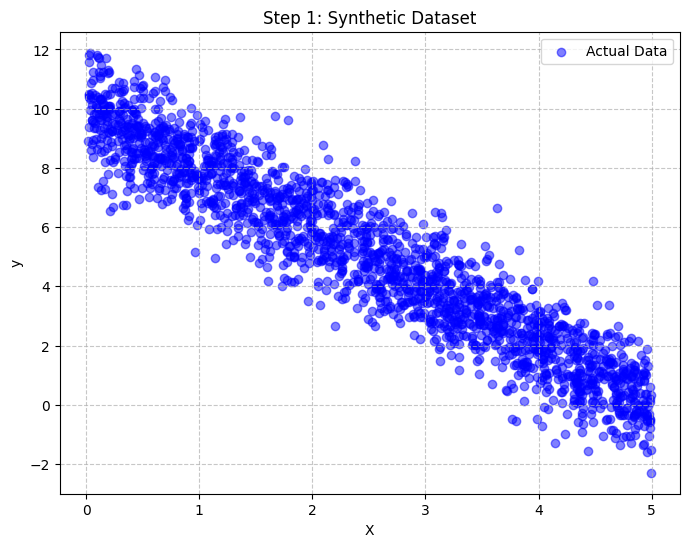

Epoch 10/100 | MSE Cost: 1.7129 | m: -1.4799, c: 8.3032
Epoch 20/100 | MSE Cost: 1.0366 | m: -1.8717, c: 9.5961
Epoch 30/100 | MSE Cost: 1.0052 | m: -1.9422, c: 9.8904
Epoch 40/100 | MSE Cost: 1.0022 | m: -1.9681, c: 9.9603
Epoch 50/100 | MSE Cost: 1.0007 | m: -1.9881, c: 9.9636
Epoch 60/100 | MSE Cost: 1.0005 | m: -1.9866, c: 9.9698
Epoch 70/100 | MSE Cost: 1.0005 | m: -1.9898, c: 9.9785
Epoch 80/100 | MSE Cost: 1.0005 | m: -1.9838, c: 9.9739
Epoch 90/100 | MSE Cost: 1.0006 | m: -1.9913, c: 9.9771
Epoch 100/100 | MSE Cost: 1.0012 | m: -1.9785, c: 9.9788

Final Learned Parameters: m = -1.9785, c = 9.9788
True Parameters: m = -2.0000, c = 10.0000


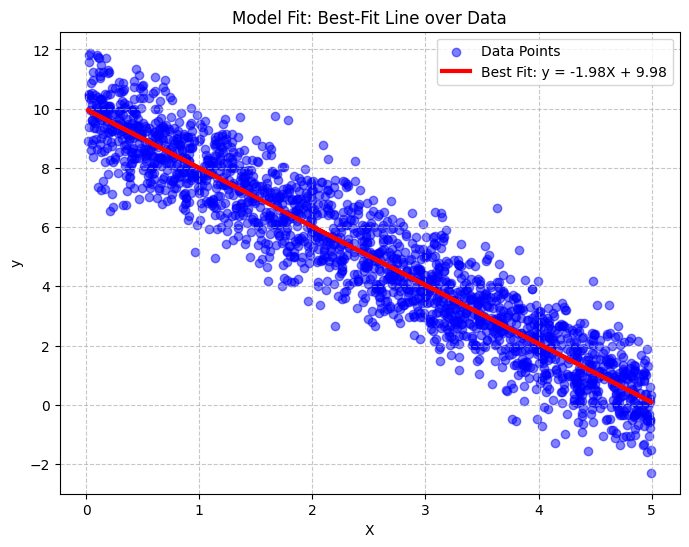

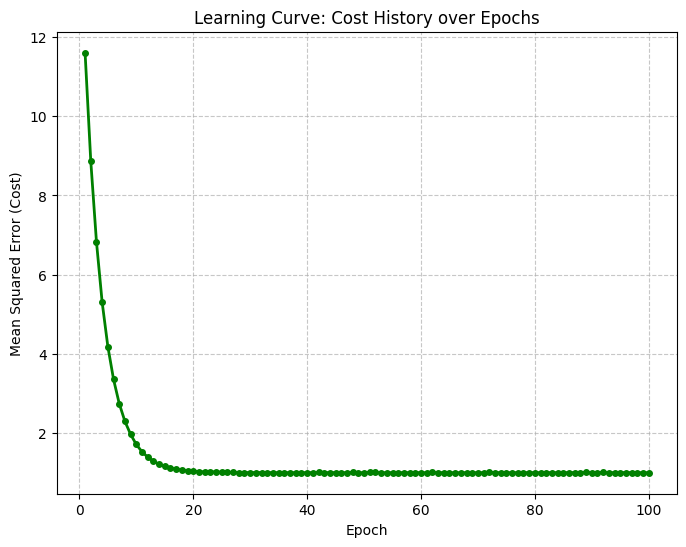

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Generate Your Dataset
# ==========================================
# Set a random seed for reproducibility
np.random.seed(42)

# Create N = 2000 data points
N = 2000

# Generate random X values (let's use a range between 0 and 5 for a nice spread)
X = 5 * np.random.rand(N, 1)

# Add random noise using np.random.randn()
noise = np.random.randn(N, 1)

# True relationship: y = 10 - 2*X + noise
y = 10 - 2 * X + noise

# Create a scatter plot to visualize the newly created data
plt.figure(figsize=(8, 6))
plt.scatter(X, y, alpha=0.5, color='blue', label='Actual Data')
plt.title('Step 1: Synthetic Dataset')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


# ==========================================
# 2. Implement Mini-Batch Gradient Descent
# ==========================================
# Set up parameters
learning_rate = 0.01
epochs = 100
batch_size = 64

# Initialize model parameters m (slope) and c (intercept) randomly
m = np.random.randn()
c = np.random.randn()

# Create a list to track the cost after each epoch
cost_history = []

# Training loop
for epoch in range(epochs):
    # Shuffle the data at the beginning of each epoch
    # We generate random indices and use them to shuffle X and y in unison
    shuffled_indices = np.random.permutation(N)
    X_shuffled = X[shuffled_indices]
    y_shuffled = y[shuffled_indices]

    # Process the data in mini-batches
    for i in range(0, N, batch_size):
        # Extract the current mini-batch
        X_batch = X_shuffled[i : i + batch_size]
        y_batch = y_shuffled[i : i + batch_size]

        # Current batch size (might be smaller than batch_size on the last iteration)
        current_batch_size = len(X_batch)

        # 1. Forward pass: Calculate predictions for the batch
        y_pred_batch = m * X_batch + c

        # 2. Calculate gradients for m and c
        # Formula for MSE gradient with respect to m: (-2/n) * sum(x * (y - y_pred))
        # Formula for MSE gradient with respect to c: (-2/n) * sum(y - y_pred)
        dm = (-2 / current_batch_size) * np.sum(X_batch * (y_batch - y_pred_batch))
        dc = (-2 / current_batch_size) * np.sum(y_batch - y_pred_batch)

        # 3. Update parameters
        m = m - learning_rate * dm
        c = c - learning_rate * dc

    # After processing all mini-batches, calculate total cost (MSE) on the ENTIRE dataset
    y_pred_full = m * X + c
    epoch_mse = np.mean((y - y_pred_full) ** 2)
    cost_history.append(epoch_mse)

    # Optional: Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | MSE Cost: {epoch_mse:.4f} | m: {m:.4f}, c: {c:.4f}")

print(f"\nFinal Learned Parameters: m = {m:.4f}, c = {c:.4f}")
print(f"True Parameters: m = -2.0000, c = 10.0000")


# ==========================================
# 3. Visualize Your Results
# ==========================================

# Plot 1: The Model Fit
plt.figure(figsize=(8, 6))
plt.scatter(X, y, alpha=0.5, color='blue', label='Data Points')
# Plot the final best-fit line
plt.plot(X, m * X + c, color='red', linewidth=3, label=f'Best Fit: y = {m:.2f}X + {c:.2f}')
plt.title('Model Fit: Best-Fit Line over Data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Plot 2: The Learning Curve
plt.figure(figsize=(8, 6))
plt.plot(range(1, epochs + 1), cost_history, color='green', linewidth=2, marker='o', markersize=4)
plt.title('Learning Curve: Cost History over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (Cost)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


How Batch Size Affects the Learning Curve

When experimenting with different `batch_size` values (e.g., 8, 128, 1024), you will notice a distinct change in the learning curve:

* **Smaller Batch Sizes (e.g., 8):** The learning curve (and the path the gradients take) becomes highly "noisy" or erratic.
* **Larger Batch Sizes (e.g., 1024):** The learning curve becomes much smoother, closely resembling standard Batch Gradient Descent.

**Why does a smaller batch size result in a noisier learning curve?**
A smaller batch size calculates the gradient (the direction to update the weights) based on a very tiny subset of the data. This small sample might not be a perfect representation of the entire dataset. For instance, a batch of 8 points might randomly contain mostly outliers, causing the model to take a "step" in the wrong direction for that specific iteration. However, because we update the weights so frequently, these noisy steps eventually average out, allowing the algorithm to zigzag its way to the global minimum.

Larger batch sizes use a more representative sample of the data for each step, resulting in a highly accurate (smooth) gradient calculation, but at the cost of requiring more memory and fewer weight updates per epoch.